In [681]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# import mne

eeg = np.load("person-2eeg_2-per-class_run-2.npy")

print(eeg.shape)

(8, 21283)


In [682]:
import numpy as np

aux = np.load("person-2aux_2-per-class_run-2.npy")

print(aux.shape)

(3, 21283)


In [683]:
print(aux[0])

[423. 398. 372. ... 335. 335. 335.]


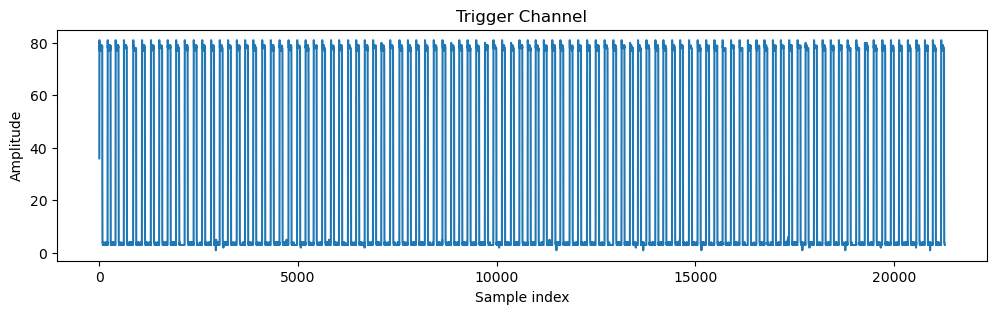

In [684]:
trigger = aux[1, :]


plt.figure(figsize=(12,3))
plt.plot(trigger)
plt.title("Trigger Channel")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

In [685]:
threshold = 80
stim_onsets = np.where(trigger[1:] > threshold)[0]
filtered_onsets = [stim_onsets[0]]

for idx in stim_onsets[1:]:
    if idx - filtered_onsets[-1] >= 10:
        filtered_onsets.append(idx)

stim_onsets = np.array(filtered_onsets)

print("Detected stimuli:", len(stim_onsets))

Detected stimuli: 93


In [686]:
print(stim_onsets)

[    2   211   411   620   854  1075  1300  1509  1721  1934  2151  2376
  2589  2815  3032  3241  3462  3670  3875  4100  4317  4538  4764  4980
  5193  5398  5610  5832  6036  6262  6466  6683  6892  7322  7555  7768
  7976  8198  8419  8640  9061  9270  9487  9921 10138 10576 10785 10985
 11189 11402 11607 11841 12053 12279 12495 12721 12938 13146 13559 13772
 13998 14198 14419 14619 14845 15062 15274 15483 15692 15900 16118 16326
 16543 16743 16956 17157 17365 17578 17991 18208 18412 18617 18838 19055
 19493 19710 19927 20131 20353 20570 20782 20983 21192]


In [687]:
# Use inter-stimulus interval (0.9 s) to estimate fs
fs = 240
dt = 1000 / fs
print(f"Estimated sampling rate: {fs:.2f} Hz")
print(dt)


Estimated sampling rate: 240.00 Hz
4.166666666666667


In [688]:
# Define ERP-related variables
epoch_start = 0    # ms
epoch_end = 700    # ms
baseline_start = 0 # ms
baseline_end = 200 # ms
erp_start = 200    # ms
erp_end = 400      # ms

hp = 0.1                        # Hz; our low cut for our bandpass
lp = 30                        # Hz; our high cut for our bandpass

print(hp)
print(lp)

baseline_duration = 0.2
baseline_duration_samples = int(baseline_duration * fs)
print(baseline_duration_samples)

sdt = np.round(dt).astype(int);

# Let's translate these from time into index space to save time later
e_s = np.round(epoch_start / sdt).astype(int)     # epoch start
e_e = np.round(epoch_end / sdt).astype(int)       # epoch end
bl_s = np.round(baseline_start / sdt).astype(int) # baseline start
bl_e = np.round(baseline_end / sdt).astype(int)   # baseline end
erp_s = np.round(erp_start / sdt).astype(int)     # ERP component window start
erp_e = np.round(erp_end / sdt).astype(int)       # ERP component window end

channels = np.array(['O1', 'O2', 'T5', 'P3', 'Pz', 'P4', 'T6', 'REF'])

num_taps = 31 
b = signal.firwin(numtaps=num_taps, cutoff=[hp, lp], pass_zero='bandpass', fs=fs)
a = 1

print(int(dt * fs))

0.1
30
48
1000


In [689]:
eeg_trials = [[],[],[],[],[],[],[],[]]
aux_trials = [[],[],[],[],[],[],[],[]]

for i, node in enumerate(eeg):
    
    filtered_eeg = signal.filtfilt(b, a, node)
    
    for j, trial in enumerate(stim_onsets):
        if j < 89:
            trial_start = int(trial - baseline_duration_samples)
            # trial_duration = int(int(dt * fs) + baseline_duration_samples)
            trial_duration = int(int(dt * fs) + baseline_duration_samples)
            # filtered_eeg = mne.filter.filter_data(eeg, sfreq=fs, l_freq=hp, h_freq=lp, verbose=False)
            trial_eeg = np.copy(filtered_eeg[trial_start:trial_start+trial_duration])
            trial_aux = np.copy(aux[trial_start:trial_start+trial_duration])
            # print(f'trial {i_trial}: ', trial_eeg.shape, trial_aux.shape)
            baseline_average = np.mean(trial_eeg[:baseline_duration_samples])
            trial_eeg -= baseline_average        
            eeg_trials[i].append(trial_eeg)
            aux_trials[i].append(trial_aux)

In [690]:
print(len(eeg_trials[0][1]))

1048


In [691]:
# Predicted targets
targets = [26, 8, 2, 13, 7, 12, 14, 6]
target_trials = []
for i in targets:
    target_trials.append(eeg_trials[0][i])

print(len(target_trials))
print(len(target_trials[3]))

8
1048


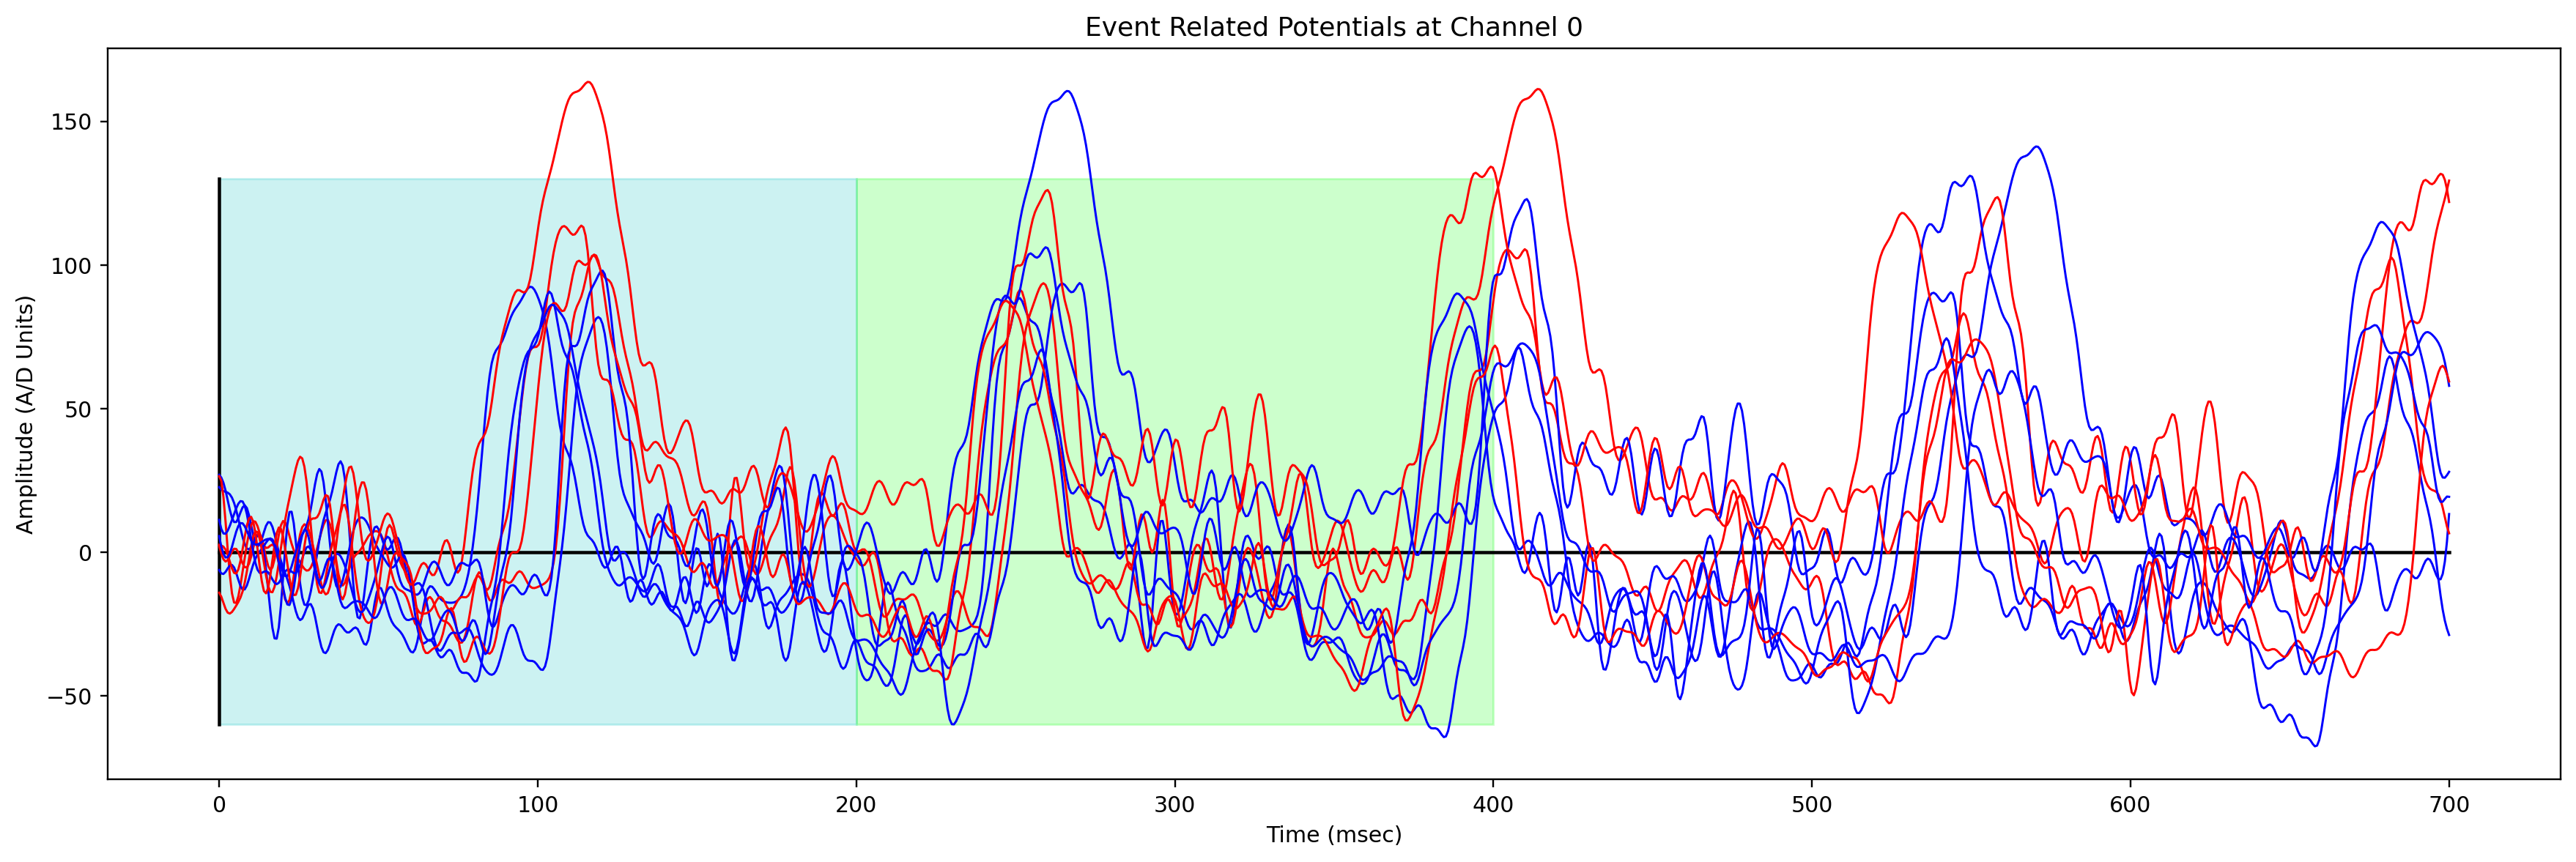

In [692]:
# Define channel of interest and create an array of time points
ch = 0
# times = np.linspace(epoch_start, epoch_end, len(eeg_trials[0][0]))
times = np.linspace(epoch_start, epoch_end, len(target_trials[1]))

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = -60
max_y = 130

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
# for i in range(len(eeg_trials[0]):
# plt.plot(times, eeg_trials[0][0], 'r', linewidth=1)
plt.plot(times, eeg_trials[0][1], 'b', linewidth=1)
plt.plot(times, eeg_trials[0][2], 'r', linewidth=1)
plt.plot(times, eeg_trials[0][3], 'b', linewidth=1)
plt.plot(times, eeg_trials[0][4], 'r', linewidth=1)
plt.plot(times, eeg_trials[0][5], 'b', linewidth=1)
plt.plot(times, eeg_trials[0][6], 'r', linewidth=1)
plt.plot(times, eeg_trials[0][7], 'b', linewidth=1)
plt.plot(times, eeg_trials[0][8], 'r', linewidth=1)
plt.plot(times, eeg_trials[0][9], 'b', linewidth=1)

# for i in range(len(target_trials)):
#     plt.plot(times, target_trials[i], 'b', linewidth=1)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)


# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.title(f'Event Related Potentials at Channel 0');
fig.set_dpi(216);
plt.show();

[[ 26.99050122  25.99823394  24.189766   ... -23.77345202 -26.6202039
  -28.77769193]
 [  2.16613612  -0.40946277  -2.4116568  ... 123.14369792 126.17385757
  129.39942235]
 [ 22.68000105  21.81488023  21.31692702 ...  -3.23507318   3.7446578
   13.32530479]
 ...
 [  9.45542446   5.28002867  -0.25046008 ... 104.73432608 103.38109793
  101.45923623]
 [-16.27157839 -15.12054741 -14.16175058 ...  87.3479125   85.32413776
   83.76046121]
 [ -6.65569003  -3.23082886   1.14723268 ...  27.95795656  25.45568786
   24.4897949 ]]


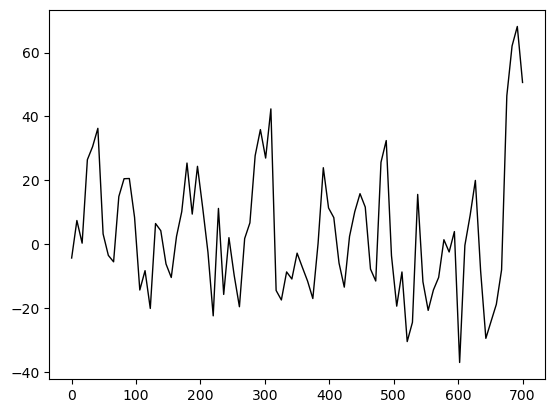

In [693]:
ch = 0

all_trials = [trial for trial in eeg_trials[ch] if len(trial) == 1048]
all_trials = np.array(all_trials)   # shape: time x trials

print(all_trials)
erp = np.mean(all_trials, axis=1)

times = np.linspace(epoch_start, epoch_end, len(erp))

plt.plot(times, erp, 'k', linewidth=1)

In [631]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Flatten epochs for clustering (channels x time → features)
n_trials, n_channels, n_samples = epochs.shape
X = epochs.reshape(n_trials, n_channels * n_samples)

# reduce dimensionality using PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

# Cluster into 2 groups (might correspond to recognized vs random)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)

# average ERP
cluster1 = epochs[labels==0].mean(axis=0)
cluster2 = epochs[labels==1].mean(axis=0)

time = np.linspace(tmin, tmax, n_samples)
plt.figure(figsize=(10,5))
plt.plot(time, cluster1[channel], label='Cluster 1')
plt.plot(time, cluster2[channel], label='Cluster 2')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("ERP Comparison by Cluster")
plt.legend()
plt.show()

ValueError: Found array with 0 feature(s) (shape=(111, 0)) while a minimum of 1 is required by PCA.

In [632]:
window_start = int((0.1 - tmin) * fs)
window_end   = int((0.3 - tmin) * fs)

response_strength = epochs[:, channel, window_start:window_end].mean(axis=1)
strongest_trials = np.argsort(response_strength)[-10:]

print("Top 10 strongest-response trials:", strongest_trials)

Top 10 strongest-response trials: [ 36  35  34  33  32  31  30  29  40 110]


C:\Users\doodl\AppData\Local\Temp\ipykernel_3700\2942244743.py:4: RuntimeWarning: Mean of empty slice.
  response_strength = epochs[:, channel, window_start:window_end].mean(axis=1)
C:\Users\doodl\anaconda3\lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Top-response trial indices: [ 0 95 26  8  2 13  7 12 14  6]


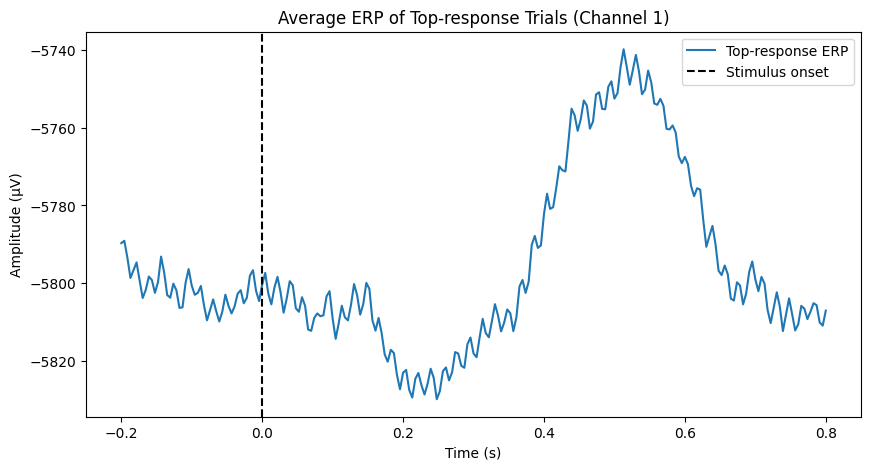

In [37]:
top_trials_idx = np.argsort(response_strength)[-10:]  # top 10 trials
print("Top-response trial indices:", top_trials_idx)

top_epochs = epochs[top_trials_idx, :, :]
erp_top = top_epochs.mean(axis=0)  # channels x samples
n_samples = erp_top.shape[1]
time = np.linspace(tmin, tmax, n_samples)

plt.figure(figsize=(10,5))
plt.plot(time, erp_top[channel], label="Top-response ERP")
plt.axvline(0, color='black', linestyle='--', label="Stimulus onset")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"Average ERP of Top-response Trials (Channel {channel+1})")
plt.legend()
plt.show()

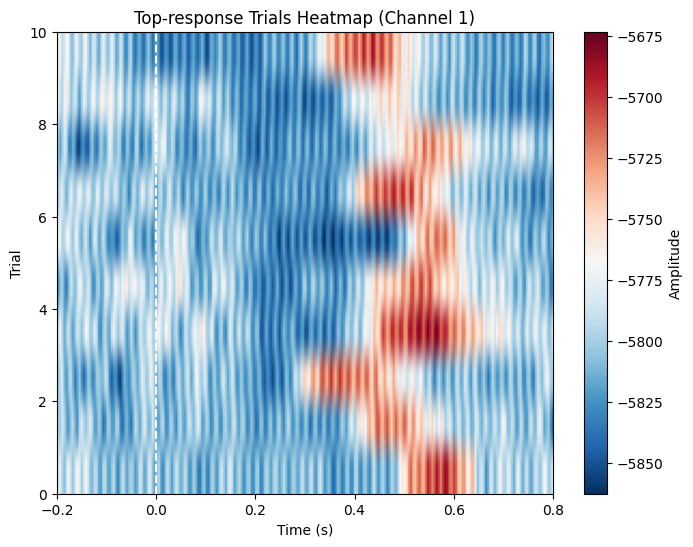

In [18]:
# Top Response Heat Map
plt.figure(figsize=(8,6))
plt.imshow(top_epochs[:, channel, :], aspect='auto', 
           extent=[tmin, tmax, 0, len(top_epochs)], cmap='RdBu_r')
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title(f"Top-response Trials Heatmap (Channel {channel+1})")
plt.show()

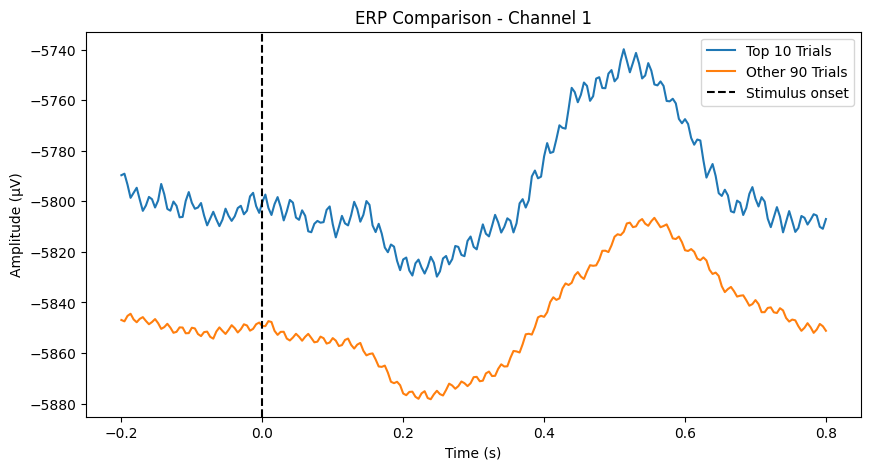

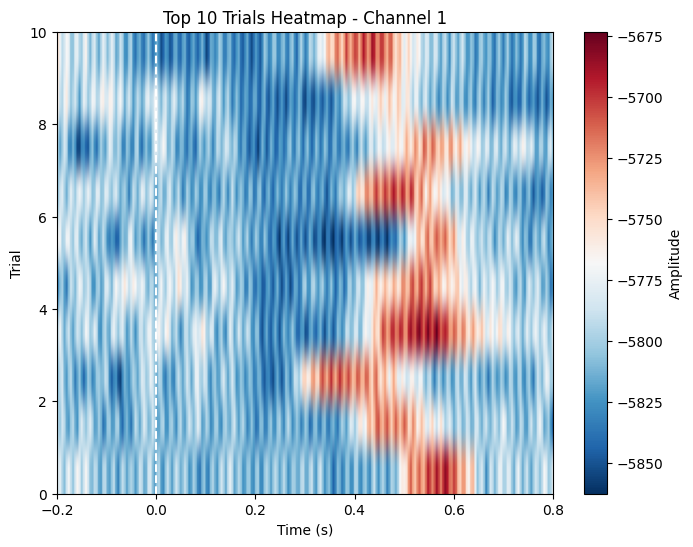

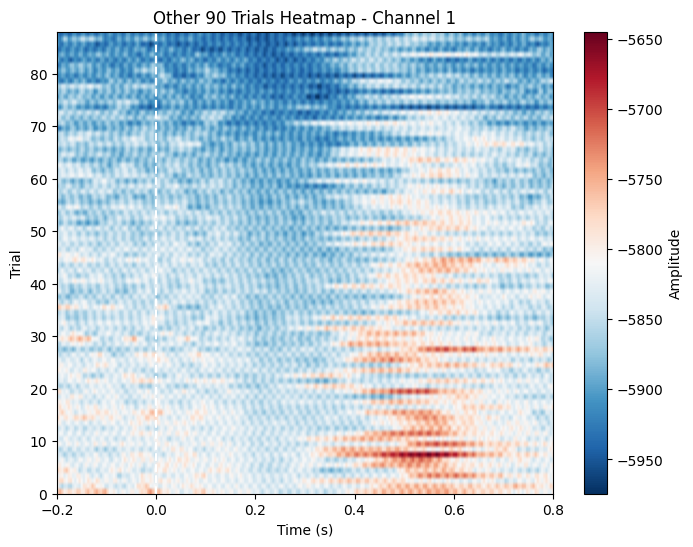

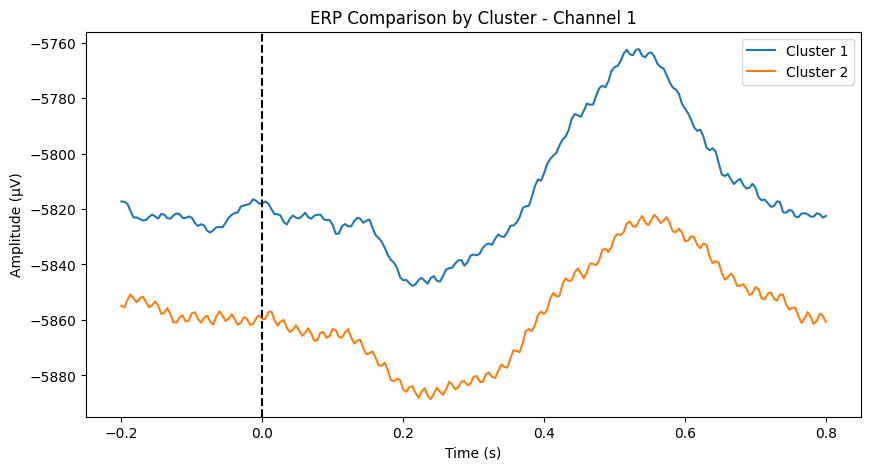

In [38]:
# Putting All Together (simpler)


top_idx = np.argsort(response_strength)[-10:]
other_idx = np.argsort(response_strength)[:-10]

top_epochs = epochs[top_idx]
other_epochs = epochs[other_idx]

erp_top = top_epochs.mean(axis=0)
erp_other = other_epochs.mean(axis=0)
n_samples = erp_top.shape[1]
time = np.linspace(tmin, tmax, n_samples)

plt.figure(figsize=(10,5))
plt.plot(time, erp_top[channel], label='Top 10 Trials')
plt.plot(time, erp_other[channel], label='Other 90 Trials')
plt.axvline(0, color='black', linestyle='--', label='Stimulus onset')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"ERP Comparison - Channel {channel+1}")
plt.legend()
plt.show()


plt.figure(figsize=(8,6))
plt.imshow(top_epochs[:, channel, :], aspect='auto',
           extent=[tmin, tmax, 0, len(top_epochs)], cmap='RdBu_r')
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title(f"Top 10 Trials Heatmap - Channel {channel+1}")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(other_epochs[:, channel, :], aspect='auto',
           extent=[tmin, tmax, 0, len(other_epochs)], cmap='RdBu_r')
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title(f"Other 90 Trials Heatmap - Channel {channel+1}")
plt.show()



n_trials, n_channels, n_samples = epochs.shape
X = epochs.reshape(n_trials, n_channels * n_samples)


pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)


kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)

cluster1 = epochs[labels==0].mean(axis=0)
cluster2 = epochs[labels==1].mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(time, cluster1[channel], label='Cluster 1')
plt.plot(time, cluster2[channel], label='Cluster 2')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"ERP Comparison by Cluster - Channel {channel+1}")
plt.legend()
plt.show()

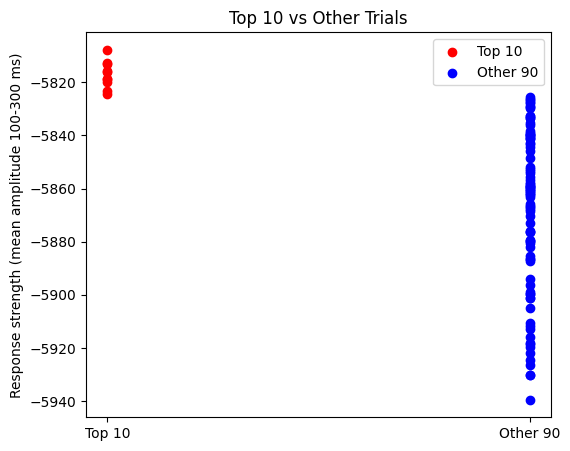

In [39]:
x_top = np.zeros(len(top_idx))
x_other = np.ones(len(other_idx))
y_top = response_strength[top_idx]
y_other = response_strength[other_idx]

plt.figure(figsize=(6,5))
plt.scatter(x_top, y_top, color='red', label='Top 10')
plt.scatter(x_other, y_other, color='blue', label='Other 90')
plt.xticks([0,1], ['Top 10', 'Other 90'])
plt.ylabel("Response strength (mean amplitude 100-300 ms)")
plt.title("Top 10 vs Other Trials")
plt.legend()
plt.show()

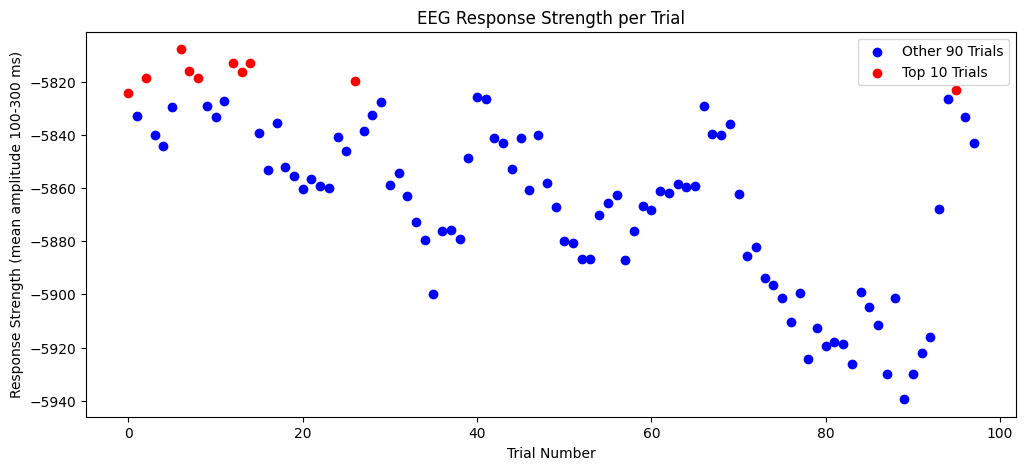

In [40]:
import matplotlib.pyplot as plt
import numpy as np

n_trials = len(response_strength)

plt.figure(figsize=(12,5))

# Other 90 trials
plt.scatter(other_idx, response_strength[other_idx], color='blue', label='Other 90 Trials')

# Top 10 trials
plt.scatter(top_idx, response_strength[top_idx], color='red', label='Top 10 Trials')

plt.xlabel("Trial Number")
plt.ylabel("Response Strength (mean amplitude 100-300 ms)")
plt.title("EEG Response Strength per Trial")
plt.legend()
plt.show()